In [4]:
# import jax
import os
import re
import hashlib
import random
import matplotlib.pyplot as plt

In [5]:
OVERIDE = True

In [6]:
from sys import version_info
python_version = f"{version_info.major}.{version_info.minor}"
print(f"Python version: {python_version}")

Python version: 3.11


In [7]:
def add_hash(prefix: str, text: str, length: int = 5) -> str:
    """
    Appends a truncated SHA-1 hash of `text` to `prefix`,
    separated by an underscore.
    """
    digest = hashlib.sha1(text.encode()).hexdigest()[:length]
    return f"{prefix}_{digest}"


In [8]:
def add_NONhash(prefix: str, text: str, length: int = 5) -> str:
    """
    Appends a truncated SHA-1 hash of `text` to `prefix`,
    separated by an underscore.
    """
    digest = text[:length]
    return f"{prefix}_{digest}"

In [9]:
def inputSequenceProcessor(sequence: str) -> str:
    """
    Processes the input sequence by removing whitespace characters,
    converting to uppercase, and ensuring it is a valid protein sequence.
    """
    sequence = "".join(sequence.split())
    
    return sequence

In [10]:
def create_directory(path: str) -> None:
    """
    Creates a directory at the specified path if it does not already exist.
    """
    if not os.path.exists(path):
        os.makedirs(path)
        print(f"Directory created: {path}")
    else:
        print(f"Directory already exists: {path}")

In [11]:
def create_directory_without_overriding(path: str) -> None:
    """
    Creates a directory at the specified path if it does not already exist.
    """
    if os.path.exists(path):
        print(f"Directory already exists: {path}")
        number = 1
        while os.path.exists(f"{path}_{number}"):
            number += 1
        path = f"{path}_{number}"
        print(f"Creating new directory: {path}")
        os.makedirs(path)
    else:
        os.makedirs(path)
        print(f"Directory created: {path}")

In [12]:
def input_features_callback(input_features):
  if display_images:
    plot_msa_v2(input_features)
    plt.show()
    plt.close()

def prediction_callback(protein_obj, length,
                        prediction_result, input_features, mode):
  model_name, relaxed = mode
  if not relaxed:
    if display_images:
      fig = plot_protein(protein_obj, Ls=length, dpi=150)
      plt.show()
      plt.close()

In [13]:
create_directory("output")

Directory already exists: output


In [14]:
model_type = "auto" #@param ["auto", "alphafold2_ptm", "alphafold2_multimer_v1", "alphafold2_multimer_v2", "alphafold2_multimer_v3", "deepfold_v1"]
#@markdown - if `auto` selected, will use `alphafold2_ptm` for monomer prediction and `alphafold2_multimer_v3` for complex prediction.
#@markdown Any of the mode_types can be used (regardless if input is monomer or complex).
num_recycles = "10" #@param ["auto", "0", "1", "3", "6", "12", "24", "48"]
#@markdown - if `auto` selected, will use `num_recycles=20` if `model_type=alphafold2_multimer_v3`, else `num_recycles=3` .
recycle_early_stop_tolerance = "auto" #@param ["auto", "0.0", "0.5", "1.0"]
#@markdown - if `auto` selected, will use `tol=0.5` if `model_type=alphafold2_multimer_v3` else `tol=0.0`.
relax_max_iterations = 200 #@param [0, 200, 2000] {type:"raw"}
#@markdown - max amber relax iterations, `0` = unlimited (AlphaFold2 default, can take very long)
pairing_strategy = "greedy" 

num_relax = 0 #@param [0, 1, 2, 3, 4, 5] {type:"raw"}
#@markdown - number of relax iterations, `0` = no relax, `1`
use_templates = True
template_mode = "none" #@param ["none", "pdb70", "pdb_seqres", "custom"]
use_amber = num_relax > 0

#@markdown #### Sample settings
#@markdown -  enable dropouts and increase number of seeds to sample predictions from uncertainty of the model.
#@markdown -  decrease `max_msa` to increase uncertainity
max_msa = "auto" #@param ["auto", "512:1024", "256:512", "64:128", "32:64", "16:32"]
num_seeds = 1 #@param [1,2,4,8,16] {type:"raw"}
use_dropout = False #@param {type:"boolean"}

num_recycles = None if num_recycles == "auto" else int(num_recycles)
recycle_early_stop_tolerance = None if recycle_early_stop_tolerance == "auto" else float(recycle_early_stop_tolerance)
if max_msa == "auto": max_msa = None

#@markdown #### Save settings
save_all = False #@param {type:"boolean"}
save_recycles = False #@param {type:"boolean"}
save_to_google_drive = False #@param {type:"boolean"}
#@markdown -  if the save_to_google_drive option was selected, the result zip will be uploaded to your Google Drive
dpi = 200 #@param {type:"integer"}
#@markdown - set dpi for image resolution

#@title Run Prediction
display_images = True #@param {type:"boolean"}

custom_template_path = None
#@markdown ### MSA options (custom MSA upload, single sequence, pairing mode)
msa_mode = "mmseqs2_uniref_env" #@param ["mmseqs2_uniref_env", "mmseqs2_uniref","single_sequence","custom"]
pair_mode = "unpaired_paired" #@param ["unpaired_paired","paired","unpaired"] {type:"string"}
#@markdown - "unpaired_paired" = pair sequences from same species + unpaired MSA, "unpaired" = seperate MSA for each chain, "paired" - only use paired sequences.
if "multimer" in model_type and max_msa is not None:
  use_cluster_profile = False
else:
  use_cluster_profile = True

In [34]:
query_sequence = "MGARASVLSGGELDKWEKIRLRPGGKKKYKLKHIVWASRELERFAVNPGLLETSEGCRQILGQLQPSLQTGSEELRSLYNTVATLYCVHQRIDVKDTKEALDKIEEEQNKSKKKAQQAAADTKAAIQMLKEKVYLAWVPAHKGIGGNEQVDKIEPLGIAPTKAKRRVVQREKRAVGIRIQRGPGRAFVTIGKIGNMRQAHCNISRAKWNNTLKQIVKGKEVKIQDNPPIPVGDIYKRWIILGLNKIVRMYSPSKLLDQGILNYSQRRQDILDLWIYHTQGYFPDWQNYTPGPGVRYPLTFGWCYKLVPVEPDKYTAFTIPSIQKQFVDVQLQTSQEVKNWMTETLLVQNANPDCKTILKALGPAATLEEMMTACQGVGGPGHKARVLAEAMSQVTNSATIMMQRGNFKGAFDLSFFPAQGQNLYPQELKNSAVSLLNATAIAVAEGTDRVIEVVQGAYRAIRHIPRRIRQGLERILL"

jobname = 'Vriti_' + "HIV"
basejobname = "".join(jobname.split())
basejobname = re.sub(r'\W+', '', basejobname)

print(f"Base job name: {basejobname}")
jobname = add_hash(basejobname, query_sequence) 

print(f"Job name: {jobname}")

Base job name: Vriti_HIV
Job name: Vriti_HIV_c16f3


In [35]:
if OVERIDE:
    create_directory(f"output/{jobname}")
else:
    create_directory_without_overriding(f"output/{jobname}")

Directory created: output/Vriti_HIV_c16f3


In [36]:
"""Create a CSV file with the query sequence."""

queries_path = os.path.join(f"output/{jobname}", f"{jobname}.csv")
with open(queries_path, "w") as text_file:
  text_file.write(f"id,sequence\n{jobname},{query_sequence}")

In [37]:
from colabfold.download import download_alphafold_params, default_data_dir
from colabfold.utils import setup_logging
from colabfold.batch import get_queries, run, set_model_type
from colabfold.plot import plot_msa_v2
from pathlib import Path
from colabfold.colabfold import plot_protein

In [38]:
a3m_file = os.path.join(f"output/{jobname}", f"{jobname}.a3m")

In [39]:
import sys
import warnings
queries, is_complex = get_queries(queries_path)
result_dir = f"output/{jobname}"
log_filename = os.path.join(f"output/{jobname}","log.txt")
setup_logging(Path(log_filename))
model_type = set_model_type(is_complex, model_type)

In [40]:
os.environ['TF_ENABLE_MLIR_BRIDGE'] = '1'
os.environ['TF_ENABLE_MLIR_GRAPH_OPTIMIZATION'] = '1'
os.environ['TF_MLIR_BRIDGE_ABORT_ON_FAILURE'] = '1'


In [41]:
# os.environ['JAX_PLATFORM_NAME'] = 'cpu'

# Enable compile logging
os.environ["JAX_LOG_COMPILES"] = "1"

# Set XLA flags for profiling (e.g., disable Eigen threading, enable HLO profiling)
# os.environ["XLA_FLAGS"] = "--xla_cpu_multi_thread_eigen=false --xla_hlo_profile"
os.environ.pop("XLA_FLAGS", None)
os.environ["JAX_LOG_COMPILES"] = "1"

import jax
jax.config.update("jax_log_compiles", True)

In [42]:
import jax
# jax.config.update("jax_platforms", "cpu")

In [43]:
jax.numpy.array([1, 2, 3])  # Ensure JAX is working
use_templates = False

In [44]:
jax.devices()

[METAL(id=0)]

{'custom_template_path': None,
 'data_dir': PosixPath('.'),
 'dpi': 200,
 'input_features_callback': <function input_features_callback at 0x10c8119e0>,
 'is_complex': False,
 'keep_existing_results': False,
 'max_msa': None,
 'model_order': [1],
 'model_type': 'alphafold2_ptm',
 'msa_mode': 'mmseqs2_uniref_env',
 'num_models': 1,
 'num_recycles': 1,
 'num_relax': 0,
 'num_seeds': 1,
 'pair_mode': 'unpaired_paired',
 'pairing_strategy': 'greedy',
 'prediction_callback': <function prediction_callback at 0x10c811da0>,
 'queries': [('Vriti_HIV_c16f3',
              'MGARASVLSGGELDKWEKIRLRPGGKKKYKLKHIVWASRELERFAVNPGLLETSEGCRQILGQLQPSLQTGSEELRSLYNTVATLYCVHQRIDVKDTKEALDKIEEEQNKSKKKAQQAAADTKAAIQMLKEKVYLAWVPAHKGIGGNEQVDKIEPLGIAPTKAKRRVVQREKRAVGIRIQRGPGRAFVTIGKIGNMRQAHCNISRAKWNNTLKQIVKGKEVKIQDNPPIPVGDIYKRWIILGLNKIVRMYSPSKLLDQGILNYSQRRQDILDLWIYHTQGYFPDWQNYTPGPGVRYPLTFGWCYKLVPVEPDKYTAFTIPSIQKQFVDVQLQTSQEVKNWMTETLLVQNANPDCKTILKALGPAATLEEMMTACQGVGGPGHKARVLAEAMSQVTNSATIMMQRGNFKGAFDLSFFPAQGQNLYPQELKNS

SUBMIT:   0%|          | 0/150 [elapsed: 00:22 remaining: ?]

2025-08-02 14:03:23,609 Timeout while submitting to MSA server. Retrying...


PENDING:   0%|          | 0/150 [elapsed: 00:26 remaining: ?]

2025-08-02 14:03:27,530 Sleeping for 9s. Reason: PENDING


...

RUNNING:  22%|██▏       | 33/150 [elapsed: 01:31 remaining: 04:49]

2025-08-02 14:04:33,292 Sleeping for 10s. Reason: RUNNING


RUNNING:  22%|██▏       | 33/150 [elapsed: 01:50 remaining: 04:49]

2025-08-02 14:04:51,339 Timeout while fetching status from MSA server. Retrying...


COMPLETE: 100%|██████████| 150/150 [elapsed: 02:08 remaining: 00:00]


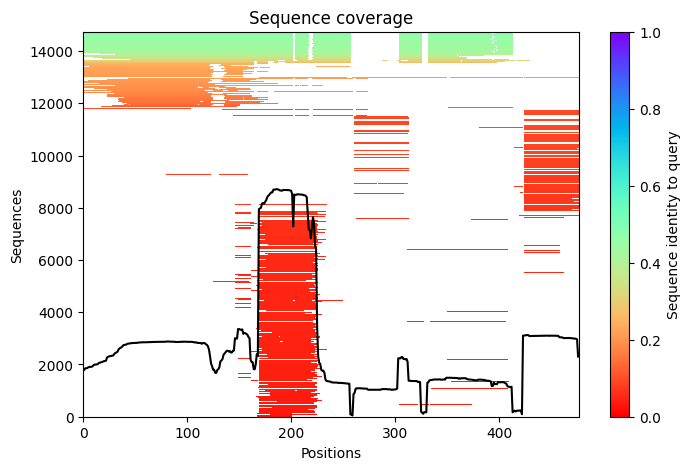

2025-08-02 14:05:12,032 Setting max_seq=512, max_extra_seq=5120
2025-08-02 14:05:15,609 Finished tracing + transforming <lambda> for pjit in 0.00021028518676757812 sec
2025-08-02 14:05:15,628 Finished tracing + transforming _einsum for pjit in 0.00045180320739746094 sec
2025-08-02 14:05:15,629 Finished tracing + transforming fn for pjit in 0.0003578662872314453 sec
2025-08-02 14:05:15,629 Finished tracing + transforming _einsum for pjit in 0.0003600120544433594 sec
2025-08-02 14:05:15,630 Finished tracing + transforming fn for pjit in 0.0002560615539550781 sec
2025-08-02 14:05:15,630 Finished tracing + transforming fn for pjit in 9.703636169433594e-05 sec
2025-08-02 14:05:15,631 Finished tracing + transforming _einsum for pjit in 0.0004050731658935547 sec
2025-08-02 14:05:15,631 Finished tracing + transforming fn for pjit in 0.0002620220184326172 sec
2025-08-02 14:05:15,632 Finished tracing + transforming fn for pjit in 0.0001583099365234375 sec
2025-08-02 14:05:15,632 Finished tracing

In [ ]:
params = dict(
    queries=queries,
    result_dir=result_dir,
    use_templates=use_templates,
    custom_template_path=custom_template_path,
    num_relax=num_relax,
    msa_mode=msa_mode,
    model_type=model_type,
    num_models=1,
    num_recycles=1,
    relax_max_iterations=relax_max_iterations,
    recycle_early_stop_tolerance=recycle_early_stop_tolerance,
    num_seeds=num_seeds,
    use_dropout=use_dropout,
    model_order=[1],
    is_complex=is_complex,
    data_dir=Path("."),
    keep_existing_results=False,
    rank_by="auto",
    pair_mode=pair_mode,
    pairing_strategy=pairing_strategy,
    stop_at_score=float(100),
    prediction_callback=prediction_callback,
    dpi=dpi,
    zip_results=False,
    save_all=save_all,
    max_msa=max_msa,
    use_cluster_profile=use_cluster_profile,
    input_features_callback=input_features_callback,
    save_recycles=save_recycles,
    user_agent="colabfold/google-colab-main",
)

# Print all inputs in one go        
import pprint
pprint.pprint(params)

# Then pass them as keyword args:
results = run(**params)


In [31]:
jobname

'Vriti_Insulin_a5e17'

In [33]:
!pwd
show_pdb(os.path.join(result_dir, f"{jobname}_unrelaxed_rank_001_alphafold2_ptm_model_1_seed_000.pdb"))

/Users/adityadude/Documents/Python/ProteinFolding


/opt/miniconda3/envs/Vriti/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [27]:
#@title Display 3D structure {run: "auto"}
import py3Dmol
import glob
import matplotlib.pyplot as plt
rank_num = 1 #@param ["1", "2", "3", "4", "5"] {type:"raw"}
color = "lDDT" #@param ["chain", "lDDT", "rainbow"]
show_sidechains = True #@param {type:"boolean"}
show_mainchains = False #@param {type:"boolean"}

def show_pdb(path, show_sidechains=False, show_mainchains=False, color="lDDT"):
  model_name = f"rank"
  view = py3Dmol.view(js='https://3dmol.org/build/3Dmol.js',)
  view.addModel(open(path,'r').read(),'pdb')

  if color == "lDDT":
    view.setStyle({'cartoon': {'colorscheme': {'prop':'b','gradient': 'roygb','min':50,'max':90}}})

  if show_sidechains:
    BB = ['C','O','N']
    view.addStyle({'and':[{'resn':["GLY","PRO"],'invert':True},{'atom':BB,'invert':True}]},
                        {'stick':{'colorscheme':f"WhiteCarbon",'radius':0.3}})
    view.addStyle({'and':[{'resn':"GLY"},{'atom':'CA'}]},
                        {'sphere':{'colorscheme':f"WhiteCarbon",'radius':0.3}})
    view.addStyle({'and':[{'resn':"PRO"},{'atom':['C','O'],'invert':True}]},
                        {'stick':{'colorscheme':f"WhiteCarbon",'radius':0.3}})
  if show_mainchains:
    BB = ['C','O','N','CA']
    view.addStyle({'atom':BB},{'stick':{'colorscheme':f"WhiteCarbon",'radius':0.3}})

  view.zoomTo()
  return view